In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
from scipy.stats import linregress

# Atividade 2.2 - Regressão Linear, p-value e métricas

## Letra A

### Função ***LinRegress***:

A função ```scipy.stats.linregress``` calcula uma regressão linear de mínimos quadrados para dois conjuntos de medições. Ela devolve a inclinação (slope), o intercepto, o coeficiente de correlação (r-value), o p-value e o erro padrão.

### Código para plotar os gráficos

In [13]:
def plot_graph(x : np.array, y : np.array, title : str):
    fig, ax = plt.subplots(figsize=(6, 5))
    
    ax.scatter(x, y, color='blue', zorder=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.scatter(x, [0.01] * len(x), color='green', zorder=10)
    ax.scatter([0.01] * len(y), y, color='pink', zorder=10)
    
    lr = linregress(x, y)
    
    line_x = np.array([0, 10])
    line_y = lr.slope * line_x + lr.intercept
    
    ax.plot(line_x, line_y, color='black', linestyle='--', linewidth=1)
    
    ax.set_xlabel('Gene X', fontsize=12)
    ax.set_ylabel('Gene Y', fontsize=12)

    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)

    plt.title(title)
    plt.grid(color='gray', linestyle='-', linewidth=0.5)
    plt.show()
    
    return lr

### Análise dos resultados

Para a geração dos 9 valores necessários para a análise, definimos uma semente para reprodutibilidade. Os valores do primeiro gráfico são $y = x$ no intervalo $[1, 9]$. Os valores do segundo são gerados de forma aleatória para o mesmo intervalo.

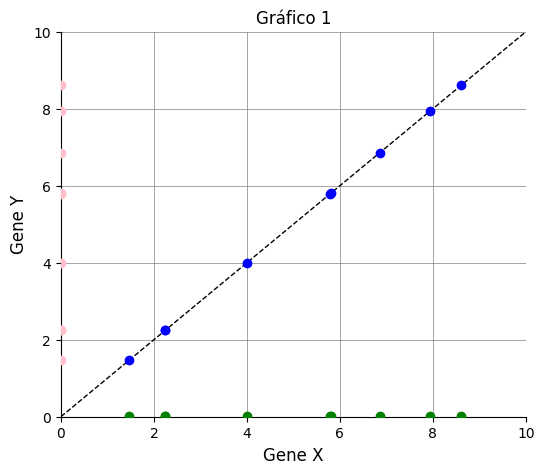

P-value: 3.2926e-70
Covariância: 6.8696


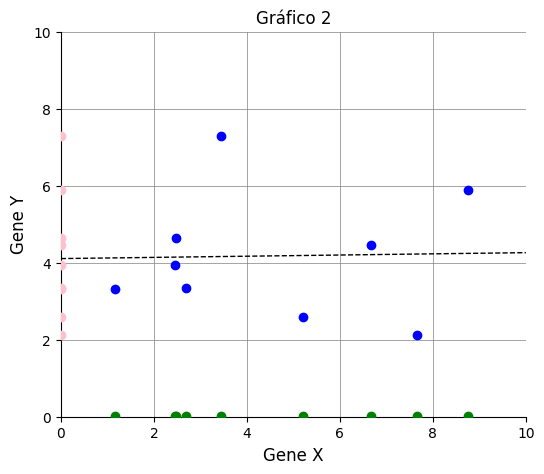

P-value: 0.9484803119891402
Covariância: 0.1098415211025765


In [32]:
np.random.seed(42)

y1 = x1 = np.sort(np.random.uniform(1, 9, 9))

x2 = np.random.uniform(1, 9, 9)
y2 = np.random.uniform(1, 9, 9)

result1 = plot_graph(x1, y1, "Gráfico 1")
covariance1 = np.cov(x1, y1)[0, 1]

print(f"P-value: {result1.pvalue:.4e}")
print(f"Covariância: {covariance1:.4f}")

result2 = plot_graph(x2, y2, "Gráfico 2")
covariance2 = np.cov(x2, y2)[0, 1]

print(f"P-value: {result2.pvalue}")
print(f"Covariância: {covariance2}")

#### **p-value**

O p-value testa a **hipótese nula** de que a inclinação da reta é zero, ou seja, que não existe correlação entre Gene X e Gene Y. 

No primeiro gráfico, observamos que o seu p-value é muito baixo, rejeitando então a **hipótese nula**. Portanto, tem uma relação estaticamente relevante entre o Gene X e o Gene Y.

Já no segundo, observamos que o seu p-value é quase $95\%$. Não podemos rejeitar a **hipotése nula**, já que mostra que o Gene X e o Gene Y não possuem correlação nenhuma.

#### **Covariância**

A covariância indica o grau de interdependência linear entre duas variáveis aleatórias, mostrando se elas se movem na mesma direção (positiva) ou em direções opostas (negativa).

No primeiro gráfico, obtemos uma covariância positiva. Já no segundo, como o valor é proximo de 0 à direita, indica que ela é ligeiramente positiva pelo acaso e não há um padrão claro de variação conjunta.

## Letra B

Usamos um *dataset* que contém dados históricos financeiros sobre o preço da prata. Possui as informações dos dias de negociações (*Date*), o preço de abertura (*Open*), o maior preço de negociação que atingiu no dia (*High*), o menor preço (*Low*), o preço final da negociação (*Close*) e o volume negociado (*Volume*). Pode-se obtê-lo no Kaggle.

In [4]:
df = pd.read_csv("../src/data/silver_prices_data.csv")
df.head()

,Date,Close,High,Low,Open,Volume
0,2011-01-24,27.318001,27.459999,26.955000,27.174999,168
1,2011-01-25,26.811001,26.950001,26.565001,26.915001,77
2,2011-01-26,27.132000,27.025000,26.684999,27.025000,49
3,2011-01-27,27.045000,27.684999,27.410000,27.684999,184
4,2011-01-28,27.934000,27.950001,26.504999,26.695000,64


Iremos utilizar apenas a coluna do preço final. Ela está na métrica **Dólares Americanos por Onça-Troy (USD/oz)**

In [5]:
df_close_prices = df['Close']
df_close_prices.head()

0    27.318001
1    26.811001
2    27.132000
3    27.045000
4    27.934000
Name: Close, dtype: float64

### Código de Plotagem

In [9]:
def plot_confidence_interval(mean : float, s_error : float, sd : float, ci : float, interval : tuple[float, float]):
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
   
    x = np.linspace(mean- 4*s_error, mean + 4*s_error, 1000)
    y = st.norm.pdf(x, mean, s_error)
    plt.plot(x, y, color='red')

    plt.axvline(mean, linestyle="--", color="black", lw=1)
    plt.axvline(interval[0], linestyle="--", color="black", lw=1)
    plt.axvline(interval[1], linestyle="--", color="black", lw=1)
    
    plt.fill_between(
        x, 0, y, 
        where=((x >= interval[0]) & (x <= interval[1])), 
        color='red', 
        alpha=0.3
        )

    plt.title(f'Nível de Confiança {ci * 100}%', fontsize=14)
    plt.xticks([interval[0], mean, interval[1]])
    plt.grid(True, alpha=0.3)

    plt.show()    

### Cálculo das métricas 

O intervalo é calculado da seguinte forma:

$$
CI = \bar{x} \pm z \frac{\sigma}{\sqrt{n}}
$$,

onde $\bar{x}$ é a média da amostra, $z$, o valor crítico; $\frac{\sigma}{\sqrt{n}}$ é o erro padrão, onde $\sigma$, o desvio padrão e $n$, o tamanho da amostra. 

Portanto, para gerar o gráfico, calculamos o **erro padrão**, **desvio padrão**, **intervalo de confiança** e a **média** para cada nível de confiança.

Tamanho da amostra: 3768
Média: 23.497272309477417
Desvio Padrão: 8.69081881208044
Intervalo de Confiaça: [23.264334857219094, 23.73020976173574]


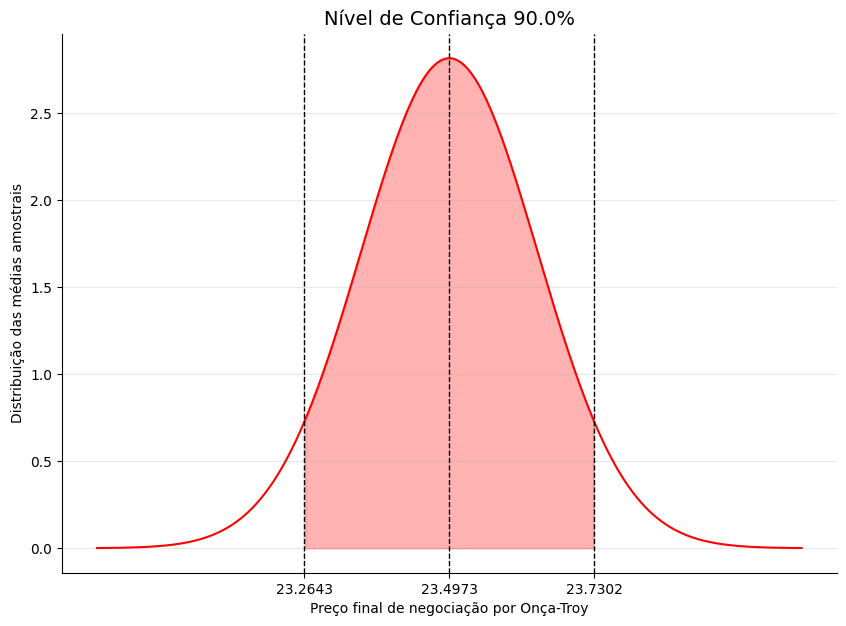

Tamanho da amostra: 3768
Média: 23.497272309477417
Desvio Padrão: 8.69081881208044
Intervalo de Confiaça: [23.219689285028643, 23.77485533392619]


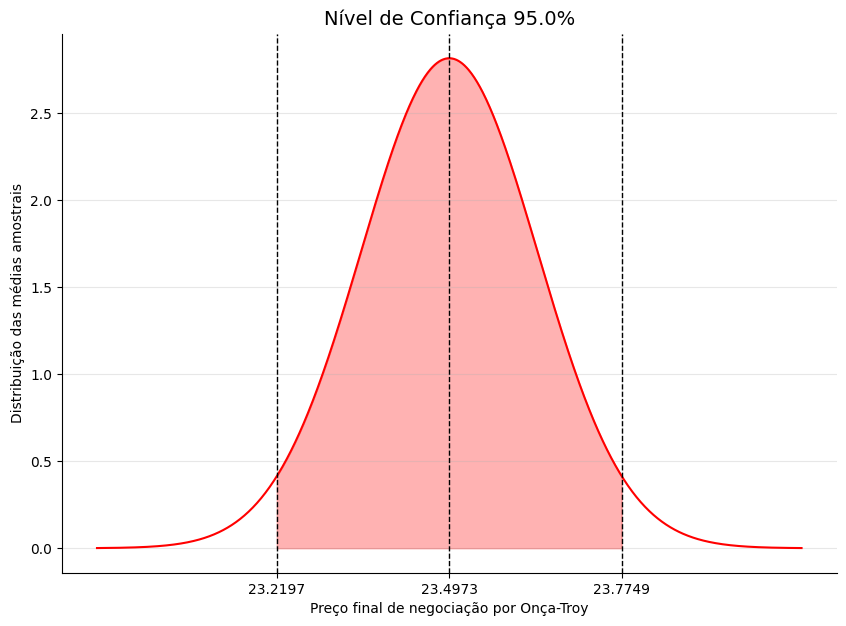

Tamanho da amostra: 3768
Média: 23.497272309477417
Desvio Padrão: 8.69081881208044
Intervalo de Confiaça: [23.13239871688576, 23.862145902069074]


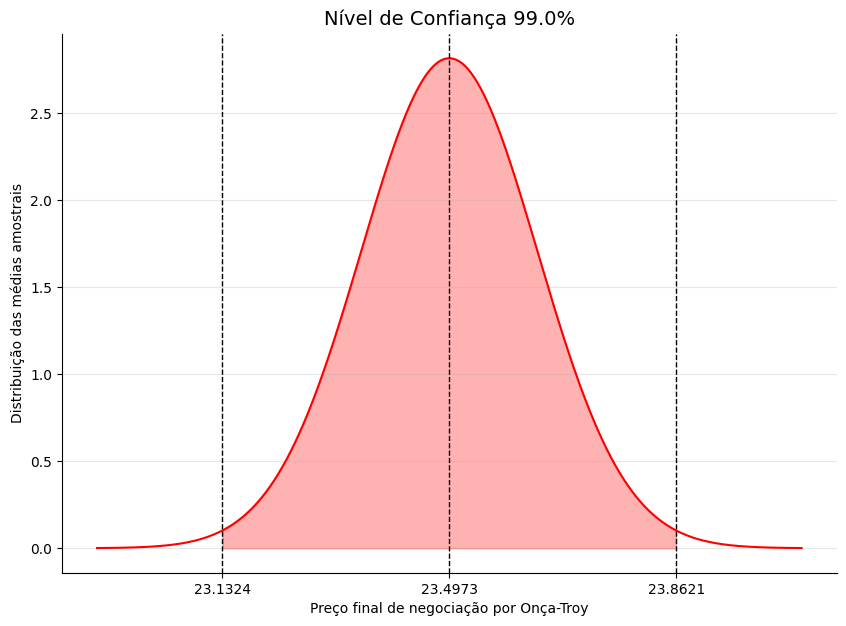

In [39]:
confidences = [0.90, 0.95, 0.99]

for confidence in confidences:
    mean = np.mean(df_close_prices)
    s_error = st.sem(df_close_prices)
    sd = np.std(df_close_prices, ddof=1)
    ci = st.t.interval(
        confidence=confidence, 
        df=len(df_close_prices)-1, 
        loc=mean, 
        scale=s_error
        )

    print(f"Tamanho da amostra: {len(df_close_prices)}")
    print(f"Média: {mean}")
    print(f"Desvio Padrão: {sd}")
    print(f"Intervalo de Confiaça: [{ci[0]}, {ci[1]}]")
    plot_confidence_interval(mean, s_error, sd, confidence, ci)

## Letra C

### Definindo os Grupos e a Hipótese Nula

Para essa tarefa, iremos usar o mesmo *dataset* do item B. Dividimos o *dataset* em dois grupos: o grupo de controle sendo os preços finais do ano de 2015 e o grupo de teste, os preços finais do ano de 2025.

In [48]:
df['Date'] = pd.to_datetime(df['Date'])

df_2015_close_prices = df[df['Date'].dt.year == 2015]["Close"]
df_2025_close_prices = df[df['Date'].dt.year == 2025]["Close"]

Nossa Hipótese Nula ($H_0$) é que não houve uma mudança significativa nos preços no intervalo de tempo definido.

In [49]:
t_stat, p_value = st.ttest_ind(df_2015_close_prices, df_2025_close_prices, equal_var=False)

print(f"P-value: {p_value}")

P-value: 2.270608331652554e-109


### Análise dos resultados

Tendo $p = 0,05$ como limiar, observamos que o *p-value* obtido é quase 0. Isso indica que é extremamente improvável que essa diferença de preço tenha acontecido por pura sorte. Portanto, podemos rejeitar a hipótese nula.

## Letra D

## Letra E

In [6]:
df_close_prices.head()

0    27.318001
1    26.811001
2    27.132000
3    27.045000
4    27.934000
Name: Close, dtype: float64

Tamanho da amostra: 50
Média: 24.25042013168335
Desvio Padrão: 8.2105754351555
Intervalo de Confiaça: [21.91700041120167, 26.583839852165028]


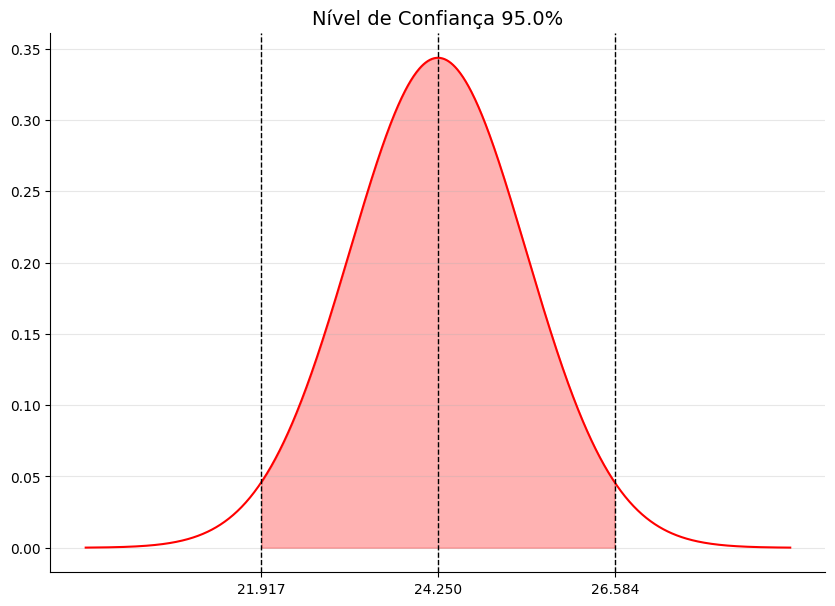

In [10]:
n = 50 

sample = df_close_prices.sample(n, random_state=42)

mean_sample = sample.mean() 
std_sample = sample.std(ddof=1) 

confidence_level = 0.95
alpha = 1 - confidence_level 

t_crit = st.t.ppf(1 - alpha/2, df=n-1)
st_error_sample = std_sample / np.sqrt(n) 

ci_lower = mean_sample - t_crit * st_error_sample 
ci_upper = mean_sample + t_crit * st_error_sample
ci = (ci_lower, ci_upper)

print(f"Tamanho da amostra: {n}")
print(f"Média: {mean_sample}")
print(f"Desvio Padrão: {std_sample}")
print(f"Intervalo de Confiaça: [{ci[0]}, {ci[1]}]")
plot_confidence_interval(mean_sample, st_error_sample, std_sample, confidence_level, ci)

Tamanho da amostra: 50
Média: 0.44
Desvio Padrão: 0.07019971509913699
Intervalo de Confiaça: [0.30241108668071887, 0.5775889133192811]


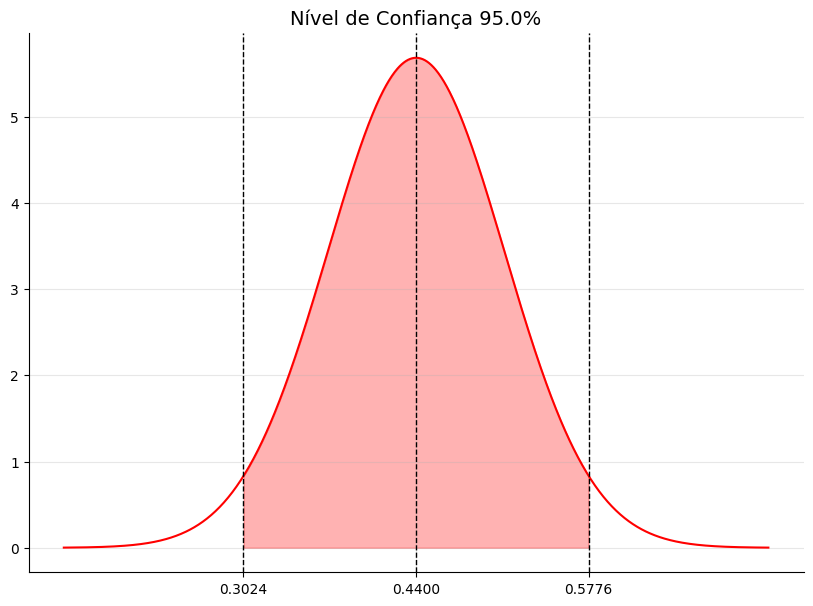

In [12]:
above_prices = (sample > 25).astype(int)

p = above_prices.mean()

z_crit = st.norm.ppf(1 - alpha/2)

st_error = np.sqrt((p * (1 - p)) / n)

ci_lower = p - z_crit * st_error 
ci_upper = p + z_crit * st_error

ci = (ci_lower, ci_upper)

print(f"Tamanho da amostra: {len(above_prices)}")
print(f"Média: {p}")
print(f"Desvio Padrão: {np.sqrt((p * (1 - p)) / n)}")
print(f"Intervalo de Confiaça: [{ci[0]}, {ci[1]}]")
plot_confidence_interval(p, st_error, np.sqrt((p * (1 - p)) / n), confidence_level, ci)

## Letra F

## Letra G

In [31]:
def pivoting_lu_matrix(a : np.array, b : np.array):
    n = len(a)

    p = np.arange(n)
    
    for k in range(n - 1):
        pivo = abs(a[k][k])
        r = k

        for i in range(k + 1, n):
            if abs(a[i][k]) > pivo:
                pivo = abs(a[i][k])
                r = i

        if pivo == 0:
            return "A matriz A é singular"

        if r != k:
            p[k], p[r] = p[r], p[k]        
            a[[k, r]] = a[[r, k]]

            print(f"Iteração {k+1}: Matriz após a troca: \n{a}")

        for i in range(k + 1, n):
            m = a[i][k] / a[k][k]
            a[i][k] = m

            for j in range(k+1, n):
                a[i][j] = a[i][j] -  m * a[k][j]

        print(f"Matriz após a eliminação {k+1}: \n{a}")

    L = np.tril(a, k=-1) + np.eye(n)
    U = np.triu(a)

    print(f"Matriz L: \n{L}")
    print(f"Matriz U: \n{U}")

    c = np.zeros(n)
    for i in range(n):
        c[i] = b[p[i]]

    print(f"Vetor C: \n{c}")

    y = np.zeros(n)
    for i in range(n):
        sum = 0
        for j in range(i):
            sum += a[i, j] * y[j]

        y[i] = c[i] - sum

    print(f"Vetor Y após resolver Ly = b: \n{y}")

    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        sum = 0
        for j in range(i + 1, n):
            sum += a[i, j] * x[j]

        x[i] = (y[i] - sum) / a[i, i]

    return x

$$
\begin{equation}
\left\{
\begin{array}{rcl}
    3x_1 + 4x_2 - x_3 &=& 9 \\
    x_1 - 2x_2 + 2x_3 &=& 3 \\
    4x_1 - 3x_3 &=& -2
\end{array}
\right.
\end{equation}
$$

In [34]:
# página 142, exemplo 7 (colocar no markdown)

a = np.array([
    [3, -4,  1],
    [1,  2,  2],
    [4,  0, -3]])

b = np.array([9, 3, -2])

solution = pivoting_lu_matrix(a, b)
print(f"A solução do sistema é: {solution}")

Iteração 1: Matriz após a troca: 
[[ 4  0 -3]
 [ 1  2  2]
 [ 3 -4  1]]
Matriz após a eliminação 1: 
[[ 4  0 -3]
 [ 0  2  2]
 [ 0 -4  3]]
Iteração 2: Matriz após a troca: 
[[ 4  0 -3]
 [ 0 -4  3]
 [ 0  2  2]]
Matriz após a eliminação 2: 
[[ 4  0 -3]
 [ 0 -4  3]
 [ 0  0  3]]
Matriz L: 
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
Matriz U: 
[[ 4  0 -3]
 [ 0 -4  3]
 [ 0  0  3]]
Vetor C: 
[-2.  9.  3.]
Vetor Y após resolver Ly = b: 
[-2.  9.  3.]
A solução do sistema é: [ 0.25 -1.5   1.  ]


## Letra H

## Letra I